# INF TC1 - TD2 (2h) - Structures de données

---

<details style="border: 1px">
<summary><strong>À lire avant de commencer</strong></summary>

### Comment utiliser ce notebook ?

Le but de votre travail est de répondre aux questions des exercices en **remplissant certaines cellules** de ce notebook.

**Ne modifiez pas les autres cellules.**

Lorsque vous voyez :

```python
# YOUR CODE HERE
raise NotImplementedError()
```

ou une fonction incomplète, vous devez compléter le code demandé.

Pensez à exécuter régulièrement les cellules de test afin de vérifier votre progression.
</details>

## Objectifs du TD

Dans ce TD, vous allez :

- manipuler plusieurs structures de données standard en Python (`list`, `dict`) ;
- implémenter des structures abstraites comme les piles, les files et les files de priorité ;
- représenter un arbre binaire complet sous forme de liste ;
- mettre en œuvre un tas et un tri par tas.

---

## Exercice 1 - Chargement et tri d'une liste

Le but de cet exercice est de charger une liste de dictionnaires et réaliser des méthodes de tri. Vous disposez pour cela d'un fichier appelé [`etudiants.txt`](etudiants.txt) où chaque ligne contient des informations sur des étudiants d'un cour. Pour commencer nous allons réaliser des tris simples et les rendre de plus en plus complexes.

### Rappel : Tri de listes

Avant de commencer quelques rappels sur les structures de donnéesss de listes et leurs tris. Voici une liste en Python :

In [ ]:
L1 = [3, 2, 4]

19


Pour la trier vous pouvez utiliser ```.sort()``` (doc)(https://docs.python.org/3/howto/sorting.html) qui modifie la liste actuelle :

In [2]:
L1 = [3, 2, 4]
L1.sort()
L1

[2, 3, 4]

Soit vous créez une nouvelle liste triée qui ne modifie pas la liste actuelle en utilisant ```sorted``` (doc)(https://docs.python.org/3/howto/sorting.html) :

In [3]:
L2 = [3, 2, 4]
L2 = sorted(L2)
L2

[2, 3, 4]

Et les deux tris sont identiques :

In [4]:
L1 == L2

True

Enfin les fonctions de tri peuvent prendre un [paramètre nommé](https://docs.python.org/3/glossary.html#term-parameter) `key` afin d'indiquer sur quel attribut de la liste réaliser le tri. Ci-dessous le tri sera appliqué sur le premier élément d'une liste de listes à trier :

In [5]:
L = [[3, "C"], [1, "A"], [2, "B"]]
L.sort(key = lambda x: x[0])
L

[[1, 'A'], [2, 'B'], [3, 'C']]

### Chargement d'un fichier en dictionnaire

Le code ci-dessous permet de charger ce fichier dans la variable `students_list`.

In [6]:
students_list = []

with open("etudiants.txt") as f:
    keys = None
    for line in f:
        l = [w.strip() for w in line.split(';')]
        if keys is None:
            keys = l
        else:
            students_list.append({k:v for k, v in zip(keys, l)})

Un échantillon du jeu de donnéess vous est donné comme suit, il s'agit une liste de dictionnaires (doc)(https://docs.python.org/3/tutorial/datastructures.html#dictionaries) :

In [7]:
students_list[0:2]

[{'nom': 'Dupond',
  'prenom': 'Pierre',
  'filiere': 'MP',
  'note': '19',
  'absences': '7'},
 {'nom': 'Dupont',
  'prenom': 'Jeanne',
  'filiere': 'MP',
  'note': '19',
  'absences': '5'}]

**Question 1.1 -** Calculez la moyenne des notes dans la liste `students_list`. Vous nommerez votre fonction `average_grade` et lui donnerez en paramètre la variable `L` qui contient la liste d'étudiant. Conseil : pensez à convertir les variables au bon type de donnéess (par ex. en utilisant `int()`ou `float()`).

In [ ]:
def average_grade(L: list) -> float:
    return sum([int(d['note']) for d in L]) / len(L)

19

La moyenne attendue de votre fonction est :

In [9]:
average_grade(students_list)

16.6

Le test ci-dessous doit donc être validé (autrement dit aucune `Exception` ne doit être lancée) :

In [10]:
assert average_grade(students_list) == 16.6

**Question 1.2 -** Trouvez la note maximale de manière _récursive_ et comparez avec la fonction `max` (qui peut prendre un argument `key` afin de comparer selon la note) données ci-dessous. Attention encore au type des donnéess.

In [27]:
def find_maximum_recursive(L: list)-> int:
    if len(L) == 1:
        return int(L[0]['note'])
    else:
        m = find_maximum_recursive(L[1:])
        k = int(L[0]['note'])
        if k > m:
            return k
        else:
            return m

In [28]:
find_maximum_recursive(students_list)

19

In [29]:
assert find_maximum_recursive(students_list) == int(max(students_list, key=lambda x: int(x["note"]))["note"])

**Question 1.3 -** Écrivez une fonction de recherche d'une paire d'étudiants qui ont la même note, et renvoyez leurs noms sous forme de `Tuple`. Conseils : 

- parcourir la liste ;
- construire un dictionnaire associant à chaque note le nom d'étudiant correspondant ;
- si une note est déjà présente dans le dictionnaire, renvoyer les deux noms associés. 

In [30]:
def find_same_grade(L: list)-> tuple:
    dict = {d['note'] : [] for d in L}
    for d in L:
        dict[d['note']].append(d['nom'])
    for note, names in dict.items():
        if len(names) > 1:
            return (names[0], names[1])
    return None


In [31]:
find_same_grade(students_list)

('Dupond', 'Dupont')

In [32]:
assert find_same_grade(students_list) == ('Dupond', 'Dupont')

**Question 1.4 (BONUS si vous avez du temps) -** Triez la liste d'étudiants par ordre croissant en implémentant un _tri par sélection_ fourni dans le pseudo-code ci-dessous (issu de [cette page](https://fr.wikipedia.org/wiki/Tri_par_s%C3%A9lection)). L'argument `key` permettra d'indiquer sur quel attribut réaliser le tri (par exemple la note). Voir l'usage de cet attribut dans la cellule de test suivante.

```
   procédure tri_selection(tableau t)
       n ← longueur(t) 
       pour i de 0 à n - 2
           min ← i       
           pour j de i + 1 à n - 1
               si t[j] < t[min], alors min ← j
           fin pour
           si min ≠ i, alors échanger t[i] et t[min]
       fin pour
   fin procédure
```

In [ ]:
def sort_selection(L: list, key = lambda x: x) -> list:
    n = len(L)
    for i in range(n-1):
        min = i
        for j in range(i+1, n):
            if key(L[j]) < key(L[min]):
                min = j
        if min != i:
            L[i], L[min] = L[min], L[i]
    return L

Comparer votre tri avec la méthode `sorted` de Python.

In [34]:
L2 = sorted(students_list, key = lambda x: int(x["note"]))
L3 = sort_selection(students_list, key = lambda x: int(x["note"]))
assert L2 == L3

## Exercice 2 : Piles et files

Désormais nous allons implémenter de nouvelles structures de manipulation de listes : les Piles et les Files. Et à terme réaliser un tri de plus en plus efficace (avec un Tas). Nous allons commencer avec la pile dont nous vous fournissons la structure de donnéesss, nommée `Pile` et disponible ci-desous:

In [35]:
class Pile:
    def __init__(self):
        self.items = []

    def push(self, item):
        self.items.append(item)

    def pop(self):
        return self.items.pop()

    def peek(self):
        return self.items[-1]

    def is_empty(self):
        return len(self.items) == 0

La pile ci-dessus a son équivalent avec la méthode `LifoQueue` du module `queue` de Python défini ci-dessous (doc)(https://docs.python.org/3/library/queue.html). Nous voyons bien que le dépilement renvoie les donnéess dans l'ordre inverse de leur empilement.

In [36]:
import queue
pile = queue.LifoQueue()

for i in range (5): 
    pile.put(i)

while not pile.empty():
    print(pile.get(), end=" ")

4 3 2 1 0 

**Question 2.1 -** Empilez les éléments de la liste `students_list` dans une instance de `Pile` et dans une instance de `LifoQueue`.
Dépilez ensuite les éléments des deux structures et comparez l’ordre dans lequel ils sont récupérés.

In [37]:
pile1 = queue.LifoQueue()
pile2 = Pile()

# YOUR CODE HERE
for student in students_list:
    pile1.put(student)
    pile2.push(student)

# Dépilement et comparaison des éléments des deux piles
while not pile2.is_empty() and not pile1.empty():
    assert pile2.pop() == pile1.get()

print("Les éléments des deux piles sont identiques dans le même ordre.")

Les éléments des deux piles sont identiques dans le même ordre.


**Question 2.2 -** Transformer la structure de Pile `Pile` en une **File** (que vous nommerez `File`) et vérifiez que vous obtenez les mêmes résultats en récupérant les données qu'avec le module `Queue()` de Python.

In [44]:
class File():
    # YOUR CODE HERE
    def __init__(self):
        self.items = []
    def push(self, item):
        self.items.append(item)
    def pop(self):
        if self.is_empty():
            return None
        return self.items.pop(0)
    def peek(self):
        if self.is_empty():
            return None
        return self.items[0]
    def is_empty(self):
        return len(self.items) == 0
    

In [45]:
file1 = queue.Queue()
file2 = File()

# YOUR CODE HERE
for student in students_list:
    file1.put(student)
    file2.push(student)

# Défilement et comparaison des éléments des deux files
while not file2.is_empty() and not file1.empty():
    assert file2.pop() == file1.get()

print("Les éléments des deux files sont identiques dans le même ordre.")

Les éléments des deux files sont identiques dans le même ordre.


**Question 2.3** - Mettez à jour votre File afin de ne pas générer d'[exception](https://docs.python.org/3/tutorial/errors.html) `IndexError`. On peut par exemple renvoyer une valeur de type `None` si aucune valeur n'est disponible. Ci-dessous un exemple de capture d'exception en Python sur lequel vous pouvez vous baser :

In [46]:
file = File()
try:
    assert file.pop() == None # si on renvoie None pour une file vide, pas d'Exception !
except IndexError:
    print("On ne doit pas générer d'exception IndexError !")

**Question 2.4** - Enfin, transformez la file (classe `Queue`) pour en faire une file de Priorité nommée `FilePriorite`. Pour rappel, une file de priorité renvoie les éléments selon un critère particulier (par exemple la note minimale des valeurs contenues dans la file). 

Conseils :

- gardez la liste des valeurs internes constamment triée lors de l'ajout de nouvelles valeurs;
- pour cela inclure la nouvelle valeur avec la méthode `push()` à la bonne place (en conservant l'ordre de la liste interne) avec `.insert(index, valeur)`

Nous vous fournissons aussi le module `PriorityQueue` qui est une file de priorité existante (doc)(https://docs.python.org/3/library/queue.html) afin de comparer le comportement de votre code.

In [47]:
from queue import PriorityQueue 
import random
    
filep = PriorityQueue()
list_random = [random.randint(1, 10) for _ in range(5)] # Liste aléatoire

for i in list_random: 
    filep.put(i)

while not filep.empty(): 
    print(filep.get(), end=" ")

1 5 6 7 7 

Remplir le code ci-dessous basé sur la file afin d'en faire une file de priorité. 

In [48]:
"""
Enfin, transformez la file pour en faire une file de Priorité. Pour rappel, une file de priorité renvoie les éléments selon un critère particulier (par exemple la note minimale des valeurs contenues dans la file). 

Conseils :

- gardez la liste des valeurs internes constamment triée lors de l'ajout de nouvelles valeurs;
- pour cela inclure la nouvelle valeur avec la méthode `push()` à la bonne place (en conservant l'ordre de la liste interne) avec `.insert(index, valeur)`
"""
class FilePriorite():
    # YOUR CODE HERE
    def __init__(self):
        self.items = []
    def push(self, item):
        index = 0
        while index < len(self.items) and self.items[index] < item:
            index += 1
        self.items.insert(index, item)
    def pop(self):
        if self.is_empty():
            return None
        return self.items.pop(0)
    def peek(self):
        if self.is_empty():
            return None
        return self.items[0]
    def is_empty(self):
        return len(self.items) == 0

In [49]:
filep1 = PriorityQueue()
filep2 = FilePriorite()

note_list = [float(student["note"]) for student in students_list]

# YOUR CODE HERE
for note in note_list:
    filep1.put(note)
    filep2.push(note)

# Défilement et comparaison des éléments des deux files de priorité
while not filep2.is_empty() and not filep1.empty():
    assert filep2.pop() == filep1.get()

print("Les éléments des deux files de priorité sont identiques dans le même ordre.")

Les éléments des deux files de priorité sont identiques dans le même ordre.


La complexité de la structure de données de file de priorité est $O(n)$ en ajout et de $O(1)$ en lecture.

## Exercice 3 : Arbre binaire complet sous forme de liste

Nous allons maintenant implémenter un **arbre binaire complet**. Cet arbre sera utile pour l'exercice suivant et la création d'une nouvelle structure de données : le `Tas`. Cet arbre binaire sera implémenté en utilisant un tableau (car il s'agit d'un arbre _complet_ où tous les niveaux sont remplis, sauf éventuellement le dernier). L'arbre binaire possède des nœuds ayant un index $i$, avec un fils gauche et un fils droit. Le tableau et l'arbre sont reliés de la façon suivante : 

- La racine a la position $i = 0$ (cette valeur sera renvoyée par la fonction `get_racine`)
- Le parent a la position $\lfloor (i - 1)/ 2 \rfloor$ (fonction `get_parent`)
- Le fils gauche a la position $2 \times i + 1$ (fonction `get_fils_gauche`)
- Le fils droit a la position  $2 \times i + 2$ (fonction `get_fils_droit`)

```
        1
       / \
      2   5
     / \  /
    3  4 6 
          

La liste correspondante :
[1, 2, 5, 3, 4, 6]
```


**Question 3.1** - Implémentez un arbre binaire sous forme de classe appelée `BinaryTree`. La classe contiendra entre autre des méthodes :
- `est_vide` qui indique si l'arbre est vide ou pas ;
- `taille` qui renvoie la taille de l'arbre binaire (longueur de la liste interne) ;
- `get_noeud`, `get_racine`, `get_parent`, `get_fils_gauche`, `get_fils_droit` prenant éventuellement un indice en argument et renvoyant un `Tuple` (valeur, indice), valeur valant `None` si le noeud correspondant est vide. 

In [54]:
class BinaryTree():
    def __init__(self, noeuds=None):
        if noeuds is None:
            self.noeuds = []
        else:
            self.noeuds = noeuds

    def est_vide(self):
        return len(self.noeuds) == 0
    
    def taille(self):
        return len(self.noeuds)
    
    def get_noeud(self, index):
        if index < len(self.noeuds):
            return (self.noeuds[index], index)
        else:
            return (None, index)
    
    def get_racine(self):
        return self.get_noeud(0)
    
    def get_parent(self, index):
        if index == 0:
            return (None, None) # La racine n'a pas de parent
        parent_index = (index - 1) // 2
        return self.get_noeud(parent_index)
    
    def get_fils_gauche(self, index):
        left_index = 2 * index + 1
        return self.get_noeud(left_index)
    
    def get_fils_droit(self, index):
        right_index = 2 * index + 2
        return self.get_noeud(right_index)

**Question 3.2** - Assurez vous que tous les tests ci-dessous sont validés.

In [55]:
# test arbre vide
tree_empty = BinaryTree()
assert tree_empty.taille() == 0
assert tree_empty.get_racine()[0] == None
assert tree_empty.get_parent(0)[0] == None
assert tree_empty.get_fils_gauche(0)[0] == None  
assert tree_empty.get_fils_droit(0)[0] == None  

In [56]:
L = [1, 2, 5, 3, 4, 6]
tree_values = BinaryTree(L)
assert tree_values.taille() == len(L) # 6
assert tree_values.get_racine()[0] == L[0] # 3
assert tree_values.get_fils_gauche(0)[0] == L[2*0+1] # 2
assert tree_values.get_fils_droit(0)[0] == L[2*0+2] # 5
assert tree_values.get_parent(1)[0] == L[0] # 5

Cette structure de donnéess sera utile pour la question suivante afin de créer un tas.

**Question 3.3** - Écrivez une fonction de parcours de l'arbre qui renvoie `True` si tous les nœuds de l'arbre présentent des valeurs inférieures à celles de leurs enfants, sinon `False`. Conseil : 

1. Proposez une approche récursive
2. Le cas d'arrêt est un noeud vide
3. L'appel récursif est déclanché en fonction de la valeur du noeud en cours et celle de ses enfants

In [57]:
def check_min_tree(T, i=0):
    # YOUR CODE HERE
    if T.get_noeud(i)[0] is None:
        return True
    valeur_noeud = T.get_noeud(i)[0]
    valeur_gauche = T.get_fils_gauche(i)[0]
    valeur_droite = T.get_fils_droit(i)[0]    
    if (valeur_gauche is not None and valeur_noeud >= valeur_gauche) or (valeur_droite is not None and valeur_noeud >= valeur_droite):
        return False
    return check_min_tree(T, 2*i+1) and check_min_tree(T, 2*i+2)

In [58]:
check_min_tree(tree_values)

True

In [59]:
assert check_min_tree(BinaryTree([1])) == True
assert check_min_tree(BinaryTree([1, 2])) == True
assert check_min_tree(BinaryTree([1, 2, 3])) == True
assert check_min_tree(BinaryTree([1, 2, 3, 4])) == True
assert check_min_tree(BinaryTree([5, 6, 4])) == False

## Exercice 4 (Bonus) : Création d'un tas et tri par tas

Nous allons désormais créer une nouvelle structure de données : le `Tas`. Celle-ci permettra à terme de réduire la complexité de manipulation d'une file de priorité, en répartissant le coût de la recherche du plus petit élément (qui sera renvoyé) entre l'ajout et la suppression. Pour rappel la file créée précédemment avait une complexité de $O(n)$ en ajout et de $O(1)$ en lecture. 
 
Nous utiliserons pour cela l'arbre binaire de la question précédente, qui est dit dans une configuration [min-heap](https://en.wikipedia.org/wiki/Min-max_heaphttps://en.wikipedia.org/wiki/Min-max_heap), où les données sont renvoyées par ordre croissant. Cette structure de données sera plus efficace en $O(log(n))$ pour l'ajout d'une nouvelle valeur (mais aussi pour le retrait).

**Question 4.1 -** Implémentez une structure de `Tas`comme suit :

1. Créez une structure de donnéesss de `Tas` similaire au `BinaryTree`
 
2. Créez une méthode `inserer`, que l'on utilisera à la place d'`ajoute`, dont le principe est le suivant :

    - Chaque nouveau noeud est rajouté comme dernier élément du tableau (à la fin donc)
    - Comparez ce nœud à son parent et si il est plus grand que ce parent inversez-le
    - Répétez tant que la condition ci-dessus est vraie et que la racine n'est pas atteinte

3. Créez une méthode `enlever` dont le principe est le suivant :

    - Enlever l'élément racine de l'arbre (premier élément du tableau)
    - Déplacer le dernier noeud de l'arbre (dernier élément du tableau) à la place de la racine de l'arbre
    - Vérifier que la racine conserve la propriété de Tas (qu'elle est inférieur à ses enfants); si ce n'est pas le cas alors implémenter une méthode `descendre` définie par la suite.

4. Créez une méthode `descendre` qui : 

    - Prend le plus petit des enfants
    - Echange sa place avec lui si il est plus petit
    - Répéte cela tant qu'il existe des enfants
    
Attention : pensez à tester si il existe un fils droit et un fils gauche lors des opération de descente lors de l'insertion.

In [62]:
class Tas():
    # YOUR CODE HERE
    def __init__(self):
        self.noeuds = []

    def taille(self):
        return len(self.noeuds)
    
    def est_vide(self):
        return len(self.noeuds) == 0
    
    def get_noeud(self, index):
        if index < len(self.noeuds):
            return (self.noeuds[index], index)
        else:
            return (None, index)
        
    def get_racine(self):
        return self.get_noeud(0)
    
    def get_parent(self, index):
        if index == 0:
            return (None, None) # La racine n'a pas de parent
        parent_index = (index - 1) // 2
        return self.get_noeud(parent_index)
    
    def get_fils_gauche(self, index):
        left_index = 2 * index + 1
        return self.get_noeud(left_index)
    
    def get_fils_droit(self, index):
        right_index = 2 * index + 2
        return self.get_noeud(right_index)

    def inserer(self, item):
        self.noeuds.append(item)
        index = len(self.noeuds) - 1
        while index > 0:
            parent_index = (index - 1) // 2
            if self.noeuds[index] < self.noeuds[parent_index]:
                self.noeuds[index], self.noeuds[parent_index] = self.noeuds[parent_index], self.noeuds[index]
                index = parent_index
            else:
                break

    def enlever(self):
        if len(self.noeuds) == 0:
            return None
        if len(self.noeuds) == 1:
            return self.noeuds.pop()
        racine = self.noeuds[0]
        self.noeuds[0] = self.noeuds.pop()
        self.descendre(0)
        return racine

    def descendre(self, index):
        mini = index
        index_gauche = 2 * index + 1
        index_droite = 2 * index + 2
        if index_gauche < len(self.noeuds) and self.noeuds[index_gauche] < self.noeuds[mini]:
            mini = index_gauche
        if index_droite < len(self.noeuds) and self.noeuds[index_droite] < self.noeuds[mini]:
            mini = index_droite
        if mini != index:
            self.noeuds[index], self.noeuds[mini] = self.noeuds[mini], self.noeuds[index]
            self.descendre(mini)

Votre tas doit valider les tests suivants :

In [63]:
# test tas vide
tas_vide = Tas()
assert tas_vide.taille() == 0
assert tas_vide.get_racine()[0] == None
assert tas_vide.get_fils_droit(0)[0] == None  
assert tas_vide.get_fils_droit(0)[0] == None  

# test tas simple
tas_simple = Tas()
tas_simple.inserer(1)
tas_simple.inserer(2)
assert tas_simple.taille() == 2

# test tas un peu plus complexe
tas = Tas()
liste = [1, 4, 10000, 2, 29, .2, 13, .5, 14, .1, 100]
liste_triee = sorted(liste)
for l in liste:
    tas.inserer(l)

assert tas.taille() == len(liste)    
assert tas.get_racine() == (liste_triee[0], 0)

while not tas.est_vide():
    assert tas.enlever() == liste_triee.pop(0)
    assert tas.taille() == len(liste_triee)

**Question 4.2 -** Implémentez un tri par tas en utilisant la structure de donnéesss de `Tas` que vous avez réalisé précédemment.

In [64]:
def triTas(l: list = []) -> list:
    t = Tas()
    # YOUR CODE HERE
    for item in l:
        t.inserer(item)
    liste_triee = []
    while not t.est_vide():
        liste_triee.append(t.enlever())
    return liste_triee

Comparez à la méthode de tri `sorted`.

In [65]:
liste = [54, 26, 93, 17, 77, 31, 44, 55, 20]
l2 = triTas(liste.copy())

assert(l2 == sorted(liste))
assert([] == triTas([]))
assert([1] == triTas([1]))
assert([1, 1] == triTas([1, 1]))

Pour information, le module `heapq` contient l'implémentation d'un tas en Python et s'utilise comme les Piles, Files, etc.

In [66]:
import heapq
tas = []

for i in range(5): 
    heapq.heappush(tas, i)

while not len(tas) == 0: 
    print(heapq.heappop(tas), end=" ")

# 0 1 2 3 4

0 1 2 3 4 

**Question 4.3 -** Comparez la performance (en temps) des méthodes de tri que vous avez implémenté dans les questions précentes.

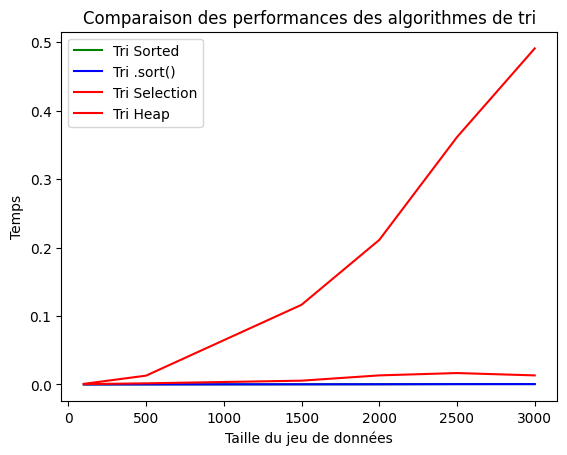

In [69]:
import time
import random
import matplotlib.pyplot as plt

nvalues = [100, 500, 1500, 2000, 2500, 3000]

timesSorted = []
timesSort = []
timesSelection = []
timesHeap = []

for i in nvalues:

    random.seed()
    p = 12**2
    liste = []
    
    for x in range(i): liste.append(random.randint(0, p))

    # tri sorted
    c = liste.copy()
    a=time.perf_counter()
    triSorted = sorted(c)
    b=time.perf_counter()
    timesSorted.append(b-a)

    # tri .sort()
    c = liste.copy()
    a=time.perf_counter()
    triSort = c
    triSort.sort()
    b=time.perf_counter()
    timesSort.append(b-a)

    # YOUR CODE HERE
    
    # tri selection
    c = liste.copy()
    a=time.perf_counter()
    triSelection = sort_selection(c)
    b=time.perf_counter()
    timesSelection.append(b-a)

    # tri heap
    c = liste.copy()
    a=time.perf_counter()
    triHeap = triTas(c)
    b=time.perf_counter()
    timesHeap.append(b-a)

plt.plot(nvalues, timesSorted, "g-", label="Tri Sorted")
plt.plot(nvalues, timesSort, "b-", label="Tri .sort()")
plt.plot(nvalues, timesSelection, "r-", label="Tri Selection")
plt.plot(nvalues, timesHeap, "r-", label="Tri Heap")
plt.xlabel("Taille du jeu de données")
plt.ylabel("Temps")
plt.legend(loc="upper left")
plt.title("Comparaison des performances des algorithmes de tri")
plt.show()

Pour en savoir plus comment Python réalise le tri, lire la documentation du `TimSort` (doc)[https://en.wikipedia.org/wiki/Timsort] qui est l'algorithme de tri utilisé.